In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from statsmodels.stats.multitest import multipletests
from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [2]:
subjects = ['LTP606', 'LTP610', 'LTP9996']

In [3]:
experiment = 'ValueCourier'
data = cml.get_data_index(kind = 'ltp')
data = data[(data['experiment']==experiment)].sort_values('session').reset_index()

full_evs = None
for i, row in data.iterrows():
    # intialize data reader, load words events and buffered eeg epochs
    r = cml.CMLReader(subject=row['subject'], experiment=row['experiment'], session=row['session'])
    evs = r.load('task_events')
    full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
full_evs = full_evs.query('subject in @subjects')
full_evs

,eegoffset,actualvalue,compensation,correctPointingDirection,eegfile,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,itemvalue,montage,msoffset,mstime,multiplier,numingroupchosen,phase,playerrotY,presX,presZ,primacybuf,protocol,recalled,recencybuf,rectime,serialpos,session,store,storeX,storeZ,storepointtype,subject,submittedPointingDirection,trial,type,valuerecall
0,23440,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761665861795,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP606,-999,0,store mappings,-999
1,31922,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-1,-999,0,-1,1761665865937,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP606,-999,0,VIDEO_START,-999
2,468068,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-1,-999,0,-1,1761666078916,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP606,-999,0,VIDEO_STOP,-999
3,646089,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761666165847,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP606,-999,0,SESS_START,-999
4,646183,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761666165893,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP606,-999,0,TL_START,-999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740,8128150,-999.0,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761342017851,0.986423,4,1,-999.0,-4.949219,10.101562,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP9996,-999,4,SESS_START,-999
741,8128152,-999.0,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761342017852,0.986423,4,1,-999.0,-4.949219,10.101562,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP9996,-999,4,REC_STOP,-999
742,8131804,-999.0,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761342019635,0.986423,4,1,-999.0,-4.949219,10.101562,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP9996,-999,4,SESS_START,-999
743,8131810,-999.0,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761342019638,0.986423,4,1,-999.0,-4.949219,10.101562,2,ltp,-999,3,-999,-999,0,-999,-999.0,-999.0,,LTP9996,-999,4,FINAL_COMPENSATION,-999


In [4]:
with open("all_items.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]               # keep upper
pool_map = {w: i+1 for i, w in enumerate(pool)}    # 1-based IDs

full_evs["itemno"]   = full_evs["item"].map(pool_map)

## Behavioral

In [5]:
pres = full_evs.type=='WORD'
recall_by_sub = full_evs[pres].groupby('subject')\
    .agg({'recalled':'mean'})\
    .rename(columns={"recalled":"Recall_Probability"}
)
recall_by_sub = recall_by_sub.reset_index()
recall_by_sub = recall_by_sub.sort_values(by="Recall_Probability", ascending=True)
sub_recall = recall_by_sub.subject.values
recall_by_sub

,subject,Recall_Probability
1,LTP610,0.320000
0,LTP606,0.360000
2,LTP9996,0.986667


In [6]:
print(f"Mean = {recall_by_sub['Recall_Probability'].mean()}, SD = {recall_by_sub['Recall_Probability'].std()}")

Mean = 0.5555555555555555, SD = 0.37388847614307746


In [7]:
spc_df = full_evs.query("type=='WORD'").groupby(
    ['subject', 'session', 'serialpos']
).agg({'recalled':np.nanmean}).reset_index()

avg_spc_df = spc_df.groupby(["subject","serialpos"]).agg({"recalled":"mean"}).reset_index()

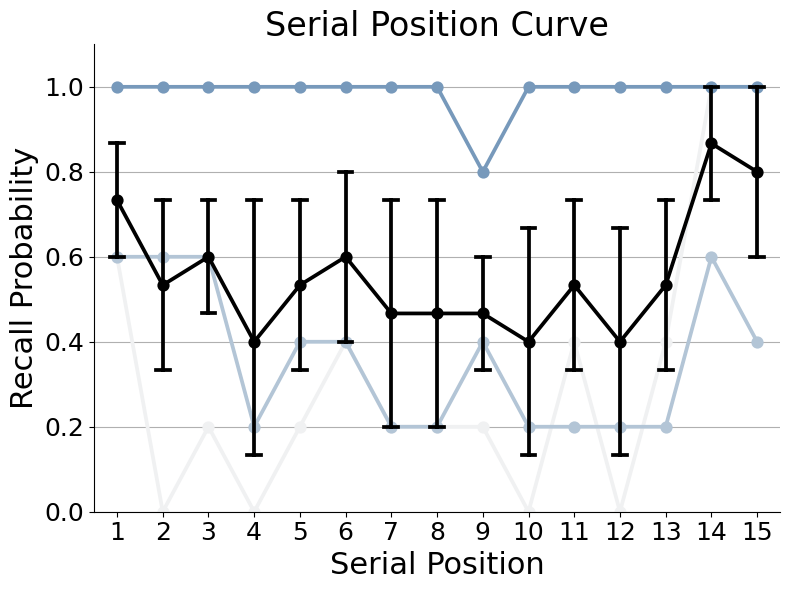

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = avg_spc_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='recalled', ci=None, ax=ax, color=colors[i])
    
spc = sns.pointplot(data=avg_spc_df, x='serialpos', y='recalled', ci=68, capsize=.3, ax=ax, color="k")

plt.title('Serial Position Curve', fontsize=24)
plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.1)
spc.yaxis.grid()
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
plt.show()

In [9]:
recword = full_evs.query('type=="REC_WORD"')
recword['pos'] = recword.groupby(['subject', 'session', 'trial']).cumcount()
first_recall_df = recword.query('pos == 0 and serialpos >= 0')
first_recall_df = first_recall_df.groupby(
    ['subject', 'serialpos']).agg(
    {'recalled': 'count'}).unstack(fill_value=0).stack().reset_index()
first_recall_df['n_lists'] = first_recall_df.groupby(['subject'])['recalled'].transform('sum')
first_recall_df['prob'] = first_recall_df['recalled'] / first_recall_df['n_lists']

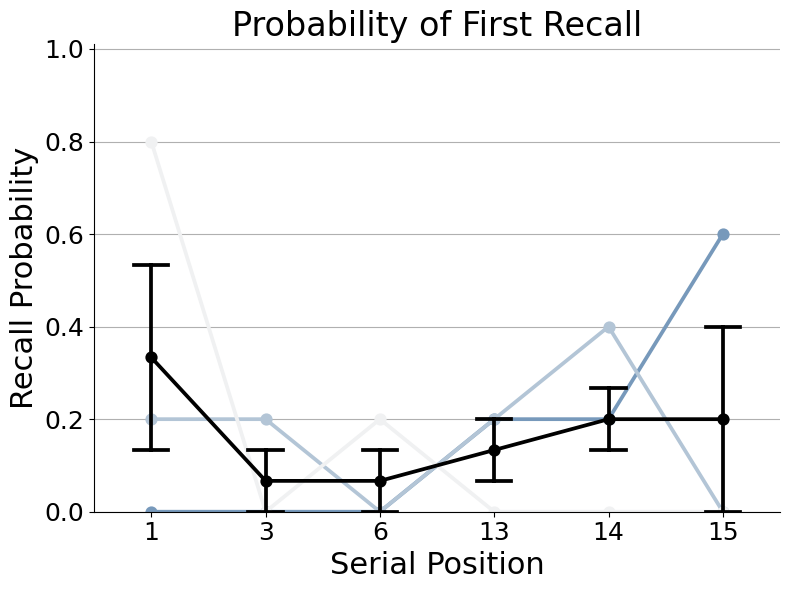

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = first_recall_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='prob', ci=None, ax=ax, color=colors[len(colors)-i-1])

spc = sns.pointplot(data=first_recall_df, x='serialpos', y='prob', ci=68, capsize=.3, ax=ax, color="k")

plt.title('Probability of First Recall', fontsize=24)
plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.01)
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
spc.yaxis.grid()
plt.show()

In [11]:
rec_word_types_all = ['REC_WORD', 'REC_WORD_VV']
present_types = set(full_evs['type'].unique())
present_rec_types = [t for t in rec_word_types_all if t in present_types]

need_types = ['WORD'] + present_rec_types
clean_evs = full_evs[full_evs['type'].isin(need_types)].copy()

for t in present_rec_types:
    if t != 'REC_WORD':
        clean_evs.loc[clean_evs['type'] == t, 'type'] = 'REC_WORD'

is_word = clean_evs['type'].eq('WORD')
is_rec  = clean_evs['type'].eq('REC_WORD')

temporal_evs = clean_evs[~(is_word & clean_evs['itemno'].isna())].copy()
temporal_evs.loc[is_rec, 'itemno'] = temporal_evs.loc[is_rec, 'itemno'].fillna(0)

temporal_evs['itemno'] = temporal_evs['itemno'].astype('int64')
temporal_evs

,eegoffset,actualvalue,compensation,correctPointingDirection,eegfile,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,itemvalue,montage,msoffset,mstime,multiplier,numingroupchosen,phase,playerrotY,presX,presZ,primacybuf,protocol,recalled,recencybuf,rectime,serialpos,session,store,storeX,storeZ,storepointtype,subject,submittedPointingDirection,trial,type,valuerecall
68,4708671,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,JEANS,115,10,0,-1,1761668149687,0.846154,4,1,84.570000,54.750000,81.562500,2,ltp,1,3,-999,1,0,clothing_store,56.718750,77.937500,Temporal,LTP606,-999,0,WORD,15
70,4841846,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,WATER_GUN,232,13,0,-1,1761668214719,0.846154,4,1,103.199997,-36.687500,-83.062500,2,ltp,1,3,-999,2,0,toy_store,-29.187500,-93.875000,Temporal,LTP606,-999,0,WORD,15
71,4888199,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,LIGHT,122,22,0,-1,1761668237354,0.846154,4,1,206.360001,23.906250,-48.093750,2,ltp,0,3,-999,3,0,bike_shop,18.671875,-51.718750,Temporal,LTP606,-999,0,WORD,15
73,5016054,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,PEARLS,154,22,0,-1,1761668299788,0.846154,4,1,2.900000,-42.656250,58.968750,2,ltp,0,3,-999,4,0,jewelry_store,-37.500000,61.000000,Temporal,LTP606,-999,0,WORD,15
74,5050863,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,NAILGUN,138,16,0,-1,1761668316786,0.846154,4,1,77.989998,-8.375000,125.312500,2,ltp,1,3,-999,5,0,hardware_store,-8.867188,131.875000,Temporal,LTP606,-999,0,WORD,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,8050949,37.866665,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,0,HELMET,111,-999,0,20,1761341980154,0.986423,4,1,-999.000000,-4.949219,10.101562,2,ltp,-999,3,37303,11,0,bike_shop,-112.062500,-30.484375,Temporal,LTP9996,-999,4,REC_WORD,38
736,8053003,37.866665,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,0,BREAD,29,-999,0,20,1761341981157,0.986423,4,1,-999.000000,-4.949219,10.101562,2,ltp,-999,3,38306,12,0,bakery,18.671875,-51.718750,Temporal,LTP9996,-999,4,REC_WORD,38
737,8055819,37.866665,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,0,KICKBOARD,118,-999,0,20,1761341982532,0.986423,4,1,-999.000000,-4.949219,10.101562,2,ltp,-999,3,39681,13,0,gym,140.750000,60.593750,Temporal,LTP9996,-999,4,REC_WORD,38
738,8059059,37.866665,9.864230,-999,/protocols/ltp/subjects/LTP9996/experiments/Va...,-1,ValueCourier,-999,-999,0,SCISSORS,186,-999,0,20,1761341984114,0.986423,4,1,-999.000000,-4.949219,10.101562,2,ltp,-999,3,41263,14,0,barber_shop,56.718750,77.937500,Temporal,LTP9996,-999,4,REC_WORD,38


In [12]:
crp_df = temporal_evs.groupby(['subject']).apply(
    pb.pd_crp,
    itemno_column='itemno',
    list_index=['subject', 'session', 'trial'],
    lag_num=14).reset_index()

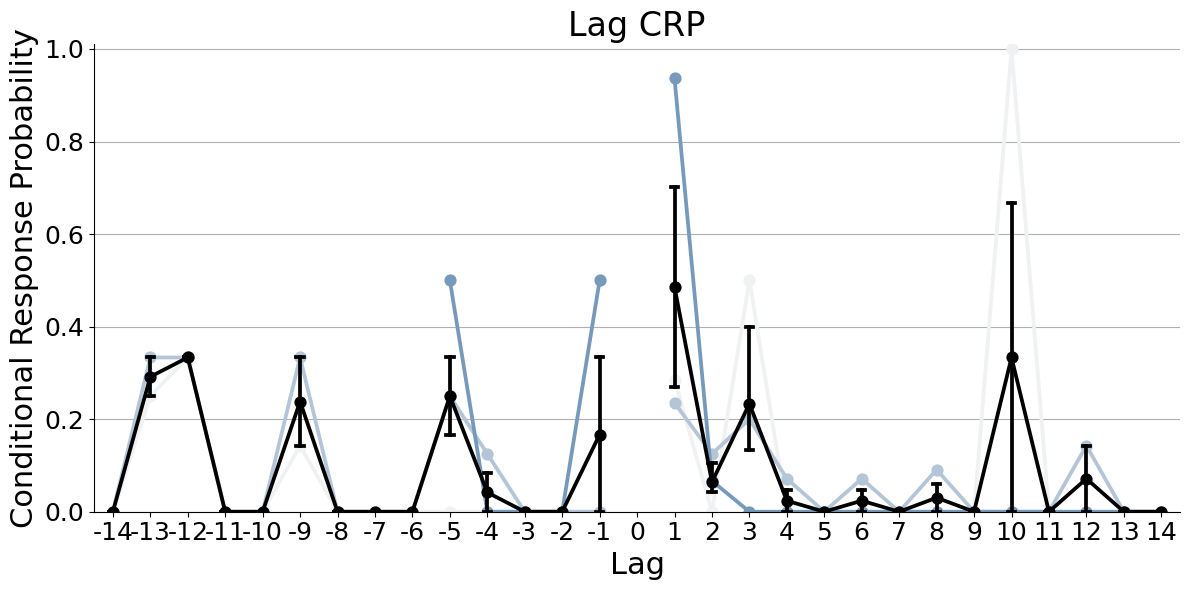

In [13]:
fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax = plt.gca()

from matplotlib.colors import ListedColormap

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_crp = crp_df.query('subject == @sub')
    sns.pointplot(data=sub_crp, x="lag", y="prob", 
                  color= colors[i], 
                  ax=ax,
                  linestyles="-")

crp = sns.pointplot(data=crp_df, x='lag', y='prob', ci=68,
                    color='k', capsize=.2, ax=ax)

ax.set_title('Lag CRP', fontsize=24)
ax.set_xlabel('Lag', fontsize=22)
ax.set_ylabel('Conditional Response Probability', fontsize=22)
ax.tick_params(labelsize=18)
plt.ylim([0,1.01])
ax.yaxis.grid()
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
temporal_clustering_df = compute_temporal_clustering(temporal_evs)
temporal_clustering_df

,subject,TC
1,LTP610,0.393782
0,LTP606,0.537329
2,LTP9996,0.980852


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/wor

                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     abs_error
No. Observations:       15          Method:                 ML       
No. Groups:             3           Scale:                  10.0313  
Min. group size:        5           Log-Likelihood:         -38.6161 
Max. group size:        5           Converged:              No       
Mean group size:        5.0                                          
---------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.108    3.923  2.832 0.005   3.420 18.797
storepointtype[T.random]  -2.778    1.669 -1.664 0.096  -6.049  0.494
TC                       -14.987   18.200 -0.823 0.410 -50.658 20.683
Recall_Probability         5.118   14.897  0.344 0.731 -24.080 34.315
Group Var                  0.053    

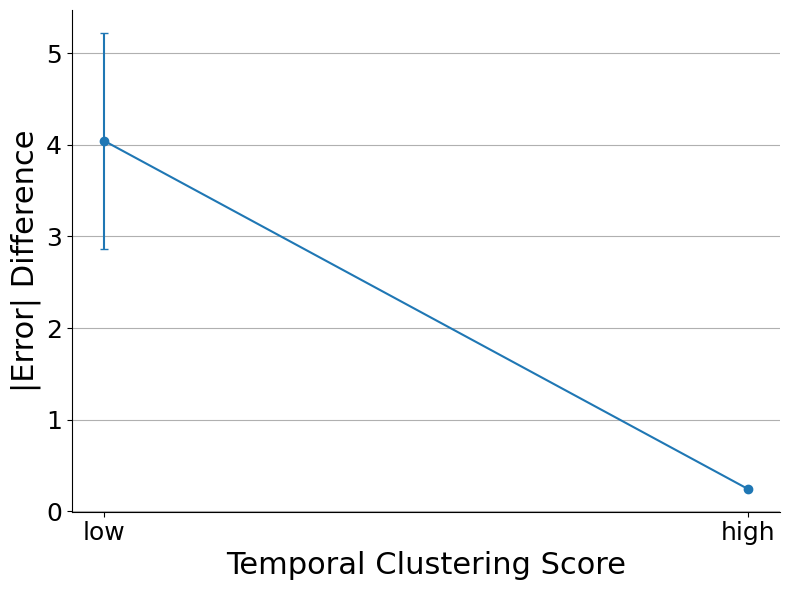

In [15]:
merged_df = get_mixed_model_fitted_error(temporal_evs, recall_by_sub)
plot_error_diff_vs_binned_cluster_score(merged_df)

In [18]:
error_by_trial = compute_trial_error(full_evs[full_evs['subject'] == 'LTP9996'])
error_by_trial

,subject,session,trial,actualvalue,valuerecall,item_count,storepointtype,abs_error
0,LTP9996,0,0,11.733334,12,15,random,0.266666
1,LTP9996,0,1,34.866665,35,15,random,0.133335
2,LTP9996,0,2,30.066668,30,15,Temporal,0.066668
3,LTP9996,0,3,13.133333,12,15,Temporal,1.133333
4,LTP9996,0,4,37.866665,38,15,Temporal,0.133335


## Encoding

In [5]:
REL_START, REL_STOP = 300, 1300
BUFFER_MS = 1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [6]:
df_idx = cml.get_data_index('ltp').query("experiment == 'ValueCourier'").copy()
if subjects is not None:
    df_idx = df_idx[df_idx['subject'].isin(subjects)]
subjects = sorted(df_idx.subject.unique())

In [47]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [8]:
def process_subject_stats(subject, exp, batch):
    sessions = cml.get_data_index('ltp').query(
        "experiment == @exp and subject == @subject"
    ).session.unique()

    n1, n0 = {}, {}
    sum1, sum0 = {}, {}
    sumsq1, sumsq0 = {}, {}
    freq_vec = FREQS

    for sess in sessions:
        ret_evs = None
        delib_evs = None
        try:
            reader = cml.CMLReader(subject=subject, experiment=exp, session=sess)
            evs_all = reader.load('task_events')
            evs_all = evs_all[(evs_all['type']=='WORD') & (evs_all['eegoffset']>=0)]
            if evs_all.empty:
                continue

            for start in range(0, len(evs_all), batch):
                evs = evs_all.iloc[start:start+batch]
                rec_mask = evs['recalled'].to_numpy().astype(bool)

                eeg = reader.load_eeg(
                    evs, rel_start=-BUFFER_MS, rel_stop=REL_STOP + BUFFER_MS, clean='LCF'
                ).to_ptsa()

                eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg)
                mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output='power', complete=True)
                pwr = mw.filter(eeg).sel(time=slice(REL_START, REL_STOP)).mean(dim='time')

                p = pwr.transpose('event', 'channel', 'frequency').values
                chans = pwr['channel'].values

                for ci, ch in enumerate(chans):
                    if ch not in n1:
                        z = np.zeros(len(freq_vec), dtype=np.float64)
                        n1[ch] = 0; n0[ch] = 0
                        sum1[ch] = z.copy(); sum0[ch] = z.copy()
                        sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

                if rec_mask.any():
                    vals = p[rec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals**2).sum(axis=0)
                    cnt = rec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum1[ch]   += s[ci]
                        sumsq1[ch] += ss[ci]
                        n1[ch]     += cnt

                nrec_mask = ~rec_mask
                if nrec_mask.any():
                    vals = p[nrec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals**2).sum(axis=0)
                    cnt = nrec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum0[ch]   += s[ci]
                        sumsq0[ch] += ss[ci]
                        n0[ch]     += cnt

                del eeg, pwr, p
                gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    if not n1:
        return pd.DataFrame(columns=['subject','channel','frequency','t'])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i,:]  = n1[ch];   N0[i,:]  = n0[ch]
        S1[i,:]  = sum1[ch]; S0[i,:]  = sum0[ch]
        SS1[i,:] = sumsq1[ch]; SS0[i,:] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=['channel','frequency']),
            columns=['t']
         ).reset_index())
    df['subject'] = subject
    return df

In [10]:
subj_chan_t_list = []

for s in subjects:
    df_sub = process_subject_stats(s, experiment, BATCH_EVENTS)
    subj_chan_t_list.append(df_sub)

Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw.fif...
    Range : 0 ... 4190207 =      0.000 ...  2046.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw-1.fif...
    Range : 4190208 ... 8380415 =   2046.000 ...  4092.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw-2.fif...
    Range : 8380416 ... 10821631 =   4092.000 ...  5284.000 secs
Ready.
Reading 0 ... 10821631  =      0.000 ...  5284.000 secs...
Not setting metadata
64 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 64 events and 6759 original time points ...
0 bad epochs dropped
CPP total time wavelet loop:  55.815648317337036
Opening raw data file /protocols/l

In [11]:
chan_t_all = (pd.concat(subj_chan_t_list, ignore_index=True)
              if subj_chan_t_list else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
chan_t_all['ROI'] = chan_t_all['channel'].map(assign_roi)
chan_t_all = chan_t_all.dropna(subset=['ROI']).copy()

subj_roi_t = (chan_t_all.groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [12]:
def one_samp(s):
    s = s.dropna()
    if s.empty: return pd.Series({'t_mean':np.nan,'p':np.nan})
    t_mean = s.mean()
    _, p = stats.ttest_1samp(s, 0.0, nan_policy='omit')
    return pd.Series({'t_mean':t_mean, 'p':p})

In [44]:
mean_tbl = (subj_roi_t
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long = (subj_roi_t
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg = mean_tbl.merge(p_tbl_long, on=['ROI','frequency'], how='outer')

heat = agg.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat.columns]
if cols_present:
    heat = heat[cols_present]

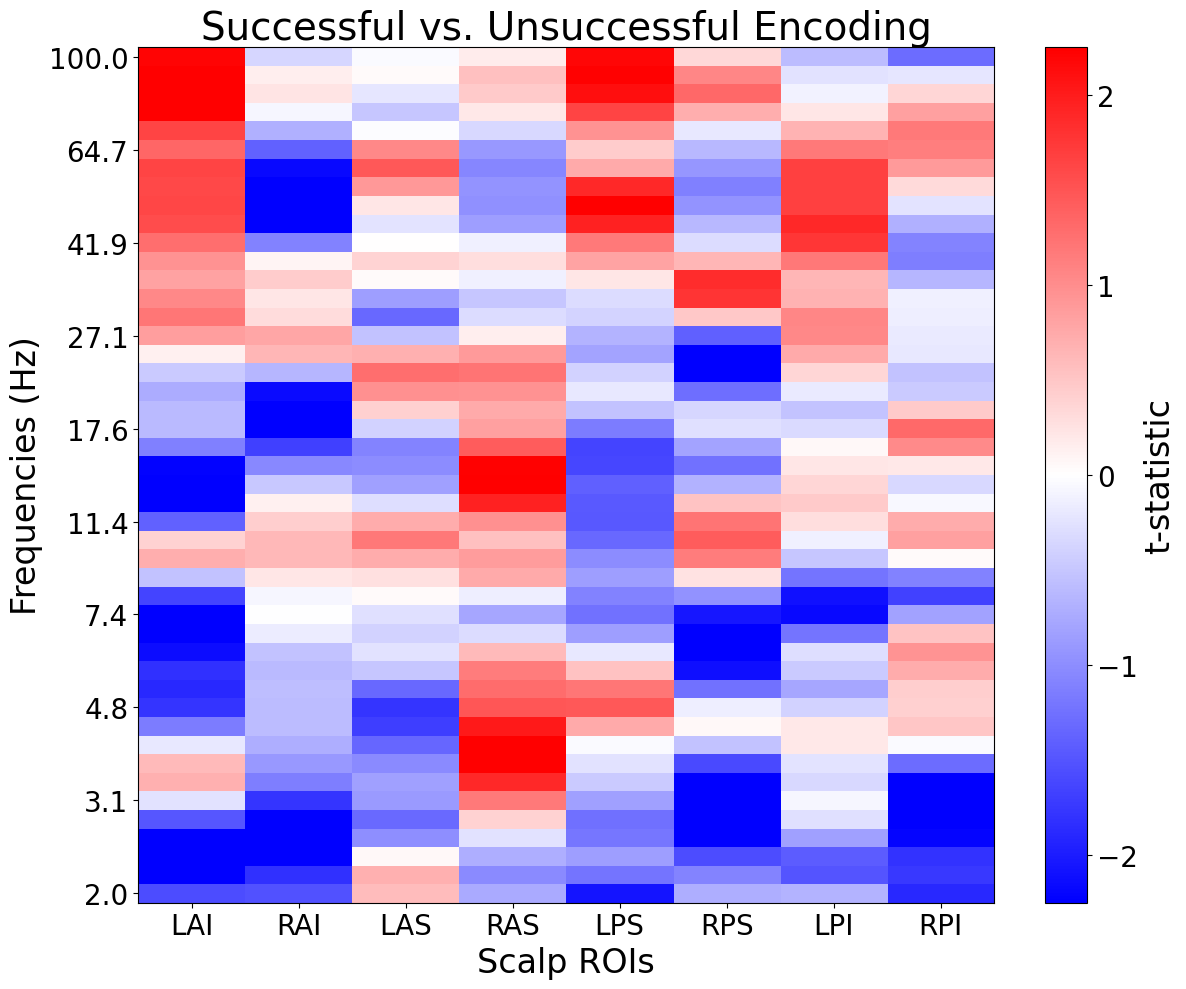

In [46]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat, cmap='bwr', aspect='auto', norm=norm)

freqs = heat.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(list(heat.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful vs. Unsuccessful Encoding', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', size=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)
plt.tight_layout()
plt.show()

## Retrieval

In [18]:
RETR_REL_START = -900
RETR_REL_STOP  =  -50
DELIB_REL_START = -900
DELIB_REL_STOP  = -50
BUFFER_MS_DELIB = 833.333333333

In [24]:
def ensure_trial_col(df):
    if 'trial' in df.columns:
        return df
    for alt in ['list', 'trialno', 'trial_num', 'trial_number']:
        if alt in df.columns:
            return df.rename(columns={alt: 'trial'})
    g = df.groupby(['subject','session'], sort=False).cumcount()
    out = df.copy()
    out['trial'] = g
    return out

In [30]:
REQUIRED_NUMERIC = ['session', 'trial', 'mstime']
OPTIONAL_NUMERIC = ['intrusion', 'serialpos', 'repetition', 'itemno', 'list', 'eegoffset']
STRING_COLS = ['type', 'eegfile', 'phase']

def prep_for_baseline(evs: pd.DataFrame) -> pd.DataFrame:
    e = evs.replace(r'^\s*$', np.nan, regex=True)
    
    for col in REQUIRED_NUMERIC + OPTIONAL_NUMERIC:
        if col in e.columns:
            e[col] = pd.to_numeric(e[col], errors='coerce')

    if 'intrusion' in e.columns:
        e['intrusion'] = e['intrusion'].fillna(0)

    if not set(REQUIRED_NUMERIC).issubset(e.columns):
        return e.iloc[0:0].copy()
    e = e.dropna(subset=REQUIRED_NUMERIC)
    
    for col in REQUIRED_NUMERIC:
        e[col] = e[col].astype(np.int64)

    for col in STRING_COLS:
        if col not in e.columns:
            e[col] = ''
        else:
            e[col] = e[col].fillna('').astype(str)

    return e

def df_to_recarray_with_dtype(df: pd.DataFrame) -> np.recarray:
    names, formats, arrays = [], [], []

    for name in df.columns:
        if name in STRING_COLS:
            arr = df[name].fillna('').astype(str).to_numpy()
            fmt = 'U128'
        else:
            dt = df[name].dtype
            if np.issubdtype(dt, np.integer):
                arr = df[name].astype(np.int64).to_numpy()
                fmt = np.int64
            elif np.issubdtype(dt, np.floating):
                arr = df[name].astype(np.float64).to_numpy()
                fmt = np.float64
            else:
                arr = df[name].fillna('').astype(str).to_numpy()
                fmt = 'U128'
        names.append(name); formats.append(fmt); arrays.append(arr)

    rec = np.rec.fromarrays(arrays, names=names, formats=formats)
    return rec

In [48]:
def process_subject_stats_retr(subject, exp, batch):
    sessions = cml.get_data_index('ltp').query(
        "experiment == @exp and subject == @subject"
    ).session.unique()

    n1, n0 = {}, {}
    sum1, sum0 = {}, {}
    sumsq1, sumsq0 = {}, {}
    freq_vec = FREQS

    for sess in sessions:
        ret_evs = None
        delib_evs = None
        try:
            reader = cml.CMLReader(subject=subject, experiment=exp, session=sess)
            evs_all = reader.load('task_events')
            if evs_all.empty:
                continue

            has_phase = 'phase' in evs_all.columns
            rec_mask = evs_all['type'].isin(['REC_START','REC_STOP','REC_WORD','REC_WORD_VV'])
            if has_phase:
                rec_mask &= (evs_all['phase'] != 'practice')
            rec_evs0 = evs_all.loc[rec_mask].reset_index(drop=True)

            if rec_evs0.empty or (rec_evs0['type'].eq('REC_START').sum()==0) or (rec_evs0['type'].eq('REC_STOP').sum()==0):
                print(f"[{subject} s{sess}] no recall bounds -> skip")
                continue

            rec_evs0 = prep_for_baseline(rec_evs0)
            if rec_evs0.empty or (rec_evs0['type'].eq('REC_WORD').sum() == 0):
                print(f"[{subject} s{sess}] cleaned table empty -> skip")
                continue

            events_rec = df_to_recarray_with_dtype(rec_evs0)
            dt = events_rec.dtype
            assert dt['eegfile'].kind in ('U','S'), f"eegfile dtype must be string, got {dt['eegfile']}"
            assert dt['phase'].kind   in ('U','S'), f"phase dtype must be string, got {dt['phase']}"
            assert dt['type'].kind    in ('U','S'), f"type dtype must be string, got {dt['type']}"

            from compute_scalp_features import create_baseline_events
            rec_evs = pd.DataFrame.from_records(
                create_baseline_events(events_rec, start_time=3000, end_time=90000)
            ).reset_index(drop=True)

            pairs = rec_evs.query("type in ['REC_WORD','REC_BASE']").copy()
            if pairs.empty:
                print(f"[{subject} s{sess}] no REC_WORD/REC_BASE -> skip")
                continue

            if 'item' in pairs.columns:
                pairs = pairs.sort_values(['session','trial','mstime'])
                pairs['repetition'] = 0
                seen = {}
                for i, row in pairs.iterrows():
                    if row['type'] != 'REC_WORD':
                        continue
                    key = (row['session'], row['trial'])
                    if key not in seen:
                        seen[key] = set()
                    if row['item'] in seen[key]:
                        pairs.at[i, 'repetition'] = 1
                    else:
                        seen[key].add(row['item'])
                pairs = pairs.query("(type == 'REC_BASE') | (repetition == 0)").copy()
                pairs.drop(columns=['repetition'], inplace=True, errors='ignore')

            if 'intrusion' in pairs.columns:
                pairs = pairs.query("intrusion == 0 or type == 'REC_BASE'").copy()

            if 'eegoffset' in pairs.columns:
                pairs = pairs[pairs['eegoffset'].fillna(0) >= 0].copy()
            if set(['eegfile','eegoffset']).issubset(pairs.columns):
                pairs = pairs.drop_duplicates(subset=['eegfile','eegoffset']).copy()

            ret_evs   = pairs[pairs['type'] == 'REC_WORD'].reset_index(drop=True)
            delib_evs = pairs[pairs['type'] == 'REC_BASE'].reset_index(drop=True)

            if ret_evs.empty and delib_evs.empty:
                print(f"[{subject} s{sess}] ret=0 delib=0 -> skip")
                continue

            mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output='power', complete=True)

            for start in range(0, max(len(ret_evs), len(delib_evs)), batch):
                ret_batch   = ret_evs.iloc[start:start+batch]
                delib_batch = delib_evs.iloc[start:start+batch]

                if not ret_batch.empty:
                    eeg_ret = reader.load_eeg(
                        ret_batch,
                        rel_start=RETR_REL_START - BUFFER_MS_DELIB,
                        rel_stop =RETR_REL_STOP  + BUFFER_MS_DELIB,
                        clean='LCF'
                    ).to_ptsa()
                    eeg_ret = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg_ret)
                    pwr_ret = mw.filter(eeg_ret).sel(time=slice(RETR_REL_START, RETR_REL_STOP)).mean(dim='time')
                    pret = pwr_ret.transpose('event', 'channel', 'frequency').values
                    chans = pwr_ret['channel'].values

                    for ci, ch in enumerate(chans):
                        if ch not in n1:
                            z = np.zeros(len(freq_vec), dtype=np.float64)
                            n1[ch] = 0; n0[ch] = 0
                            sum1[ch] = z.copy(); sum0[ch] = z.copy()
                            sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()
                    if pret.shape[0] > 0:
                        s  = pret.sum(axis=0); ss = (pret**2).sum(axis=0); cnt = pret.shape[0]
                        for ci, ch in enumerate(chans):
                            sum1[ch]   += s[ci]
                            sumsq1[ch] += ss[ci]
                            n1[ch]     += cnt
                    del eeg_ret, pwr_ret, pret

                if not delib_batch.empty:
                    eeg_del = reader.load_eeg(
                        delib_batch,
                        rel_start=DELIB_REL_START - BUFFER_MS_DELIB,
                        rel_stop =DELIB_REL_STOP  + BUFFER_MS_DELIB,
                        clean='LCF'
                    ).to_ptsa()
                    eeg_del = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg_del)
                    pwr_del = mw.filter(eeg_del).sel(time=slice(DELIB_REL_START, DELIB_REL_STOP)).mean(dim='time')
                    pdel = pwr_del.transpose('event', 'channel', 'frequency').values
                    chans = pwr_del['channel'].values

                    for ci, ch in enumerate(chans):
                        if ch not in n0:
                            z = np.zeros(len(freq_vec), dtype=np.float64)
                            n1[ch] = 0; n0[ch] = 0
                            sum1[ch] = z.copy(); sum0[ch] = z.copy()
                            sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()
                    if pdel.shape[0] > 0:
                        s  = pdel.sum(axis=0); ss = (pdel**2).sum(axis=0); cnt = pdel.shape[0]
                        for ci, ch in enumerate(chans):
                            sum0[ch]   += s[ci]
                            sumsq0[ch] += ss[ci]
                            n0[ch]     += cnt
                    del eeg_del, pwr_del, pdel

                gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    if not n1:
        return pd.DataFrame(columns=['subject','channel','frequency','t'])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i,:]  = n1[ch];   N0[i,:]  = n0[ch]
        S1[i,:]  = sum1[ch]; S0[i,:]  = sum0[ch]
        SS1[i,:] = sumsq1[ch]; SS0[i,:] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=['channel','frequency']),
            columns=['t']
         ).reset_index())
    df['subject'] = subject
    return df

In [31]:
subj_chan_t_list_retr = []

for s in subjects:
    df_sub = process_subject_stats_retr(s, experiment, BATCH_EVENTS)
    subj_chan_t_list_retr.append(df_sub)

Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw.fif...
    Range : 0 ... 4190207 =      0.000 ...  2046.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw-1.fif...
    Range : 4190208 ... 8380415 =   2046.000 ...  4092.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw-2.fif...
    Range : 8380416 ... 10821631 =   4092.000 ...  5284.000 secs
Ready.
Reading 0 ... 10821631  =      0.000 ...  5284.000 secs...
Not setting metadata
27 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 27 events and 5155 original time points ...
0 bad epochs dropped
CPP total time wavelet loop:  17.942166566848755
Opening raw data file /protocols/l

In [32]:
chan_t_all_retr = (pd.concat(subj_chan_t_list_retr, ignore_index=True)
              if subj_chan_t_list_retr else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
chan_t_all_retr['ROI'] = chan_t_all_retr['channel'].map(assign_roi)
chan_t_all_retr = chan_t_all_retr.dropna(subset=['ROI']).copy()

subj_roi_t_retr = (chan_t_all_retr.groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [37]:
mean_tbl_retr = (subj_roi_t_retr
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long_retr = (subj_roi_t_retr
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg_retr = mean_tbl_retr.merge(p_tbl_long_retr, on=['ROI','frequency'], how='outer')

heat_retr = agg_retr.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat_retr.columns]
if cols_present:
    heat_retr = heat_retr[cols_present]

p_tbl_retr = agg_retr.pivot(index='frequency', columns='ROI', values='p')
if cols_present:
    p_tbl_retr = p_tbl_retr[cols_present]

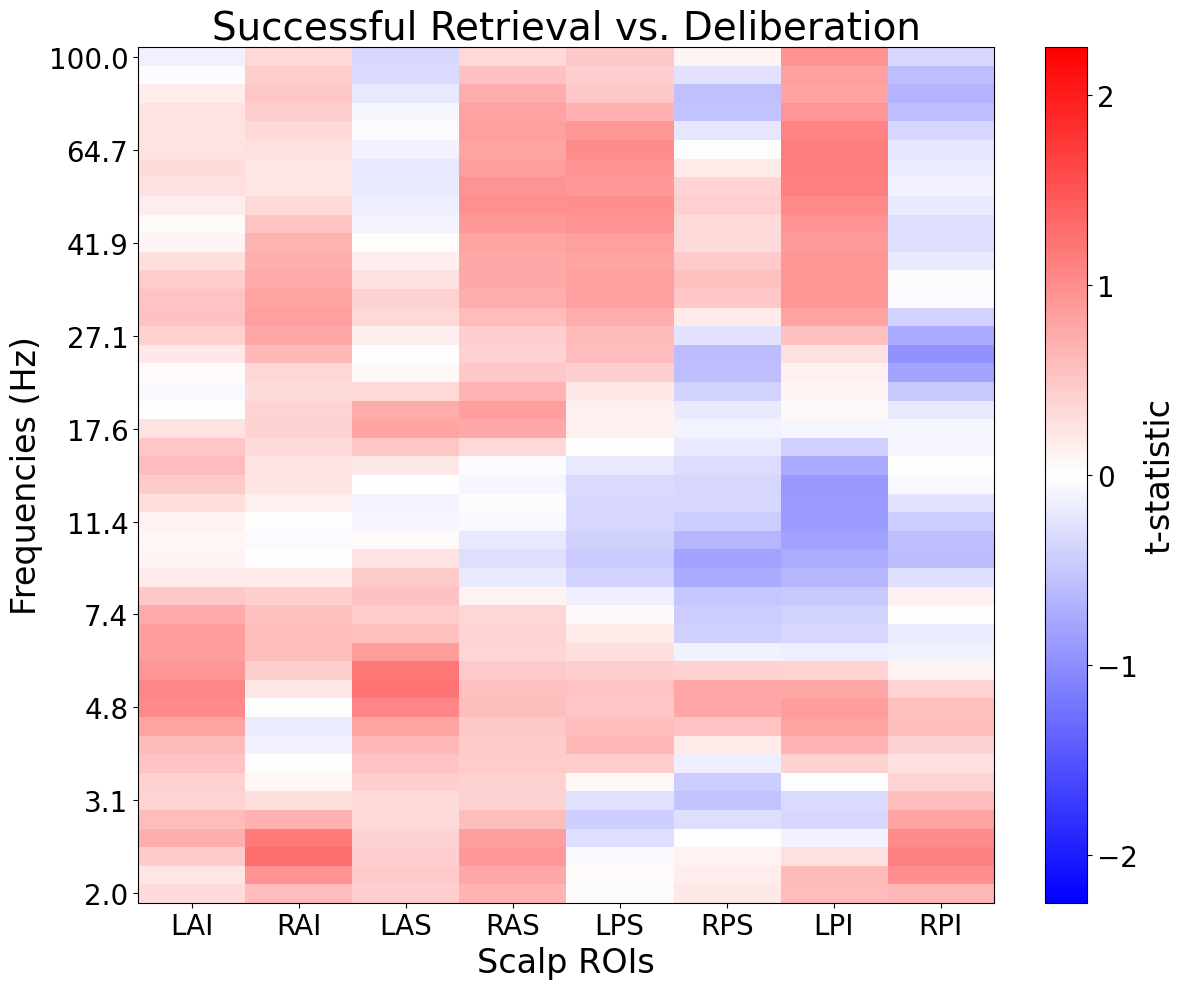

In [38]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat_retr, cmap='bwr', aspect='auto', norm=norm)

freqs = heat_retr.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat_retr.shape[1]))
ax.set_xticklabels(list(heat_retr.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful Retrieval vs. Deliberation', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', fontsize=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)
plt.tight_layout()
plt.show()